In [22]:
import matplotlib.pyplot as plt
import matplotlib
import numpy

from rascil.processing_components import plot_uvcoverage, plot_visibility

from radioimaging.images import images
from radioimaging.util import util
from radioimaging.visibility import bda, ingest

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [8, 5]

In [23]:
dataset_name = "../data8/midbda100.ms"
output_dataset_name = "../data8/midbda99.ms"
npix = 512
cell_size_rad = 8.75517e-07
cell_size_deg = cell_size_rad * 180 / numpy.pi
field_size_deg = cell_size_deg * npix 

decorr_limit = 0.99

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.
/home/sunwang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_i

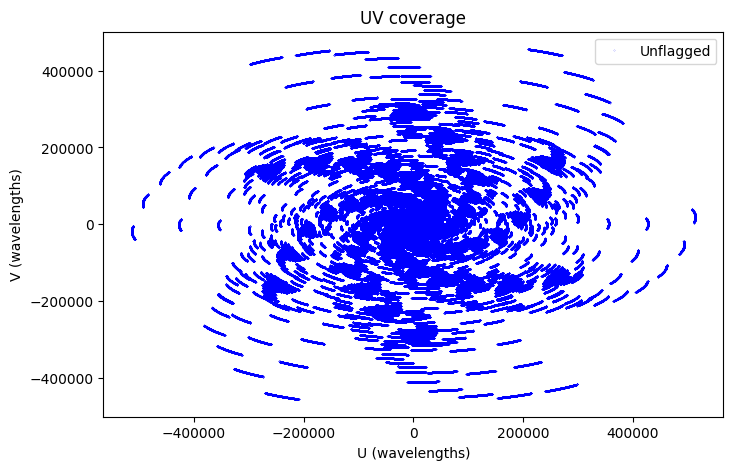

[0,
 0.45228054864768097,
 1.8091221945907239,
 6.331927681067533,
 33.01648005128071,
 231.11536035896498]

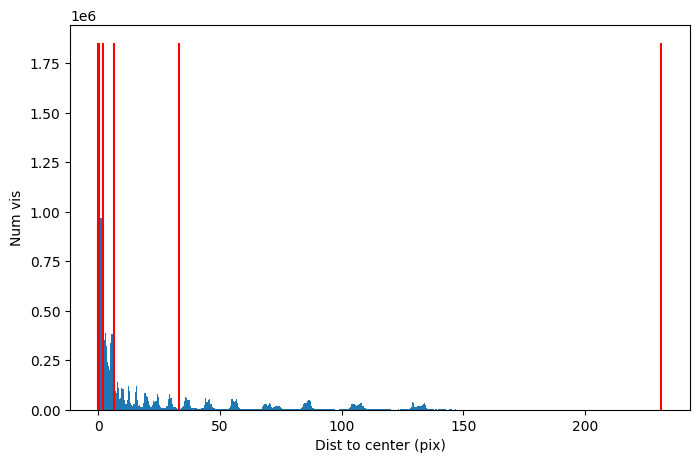

In [24]:
from rascil.processing_components import create_visibility_from_ms

[vfull] = create_visibility_from_ms(dataset_name)
plot_uvcoverage([vfull])
bda.generate_telescope_histogram(vfull, show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=cell_size_rad, output_file="../figures/bda100.png")

/home/sunwang/.local/lib/python3.10/site-packages/ska_sdp_datamodels/visibility/vis_model.py:190: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'baselines' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  return cls(datavars, coords=coords, attrs=attrs)
There is no flagged visibility. Skip plotting flagged.


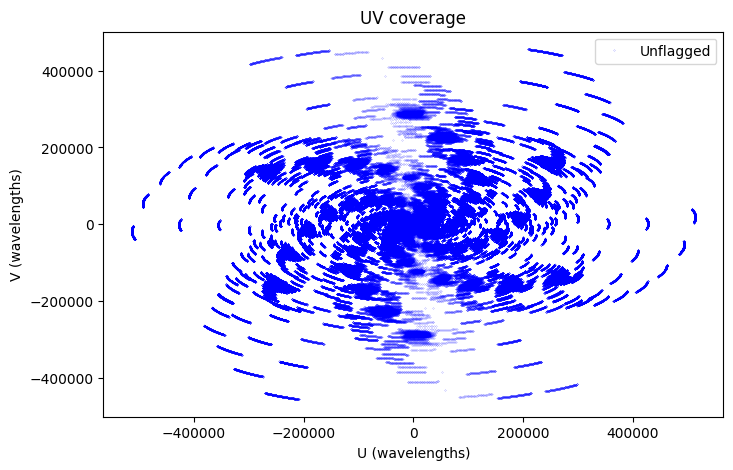

[0,
 28.94547086300809,
 66.0318554062372,
 87.74095855349327,
 130.7068918657709,
 231.11149392183023]

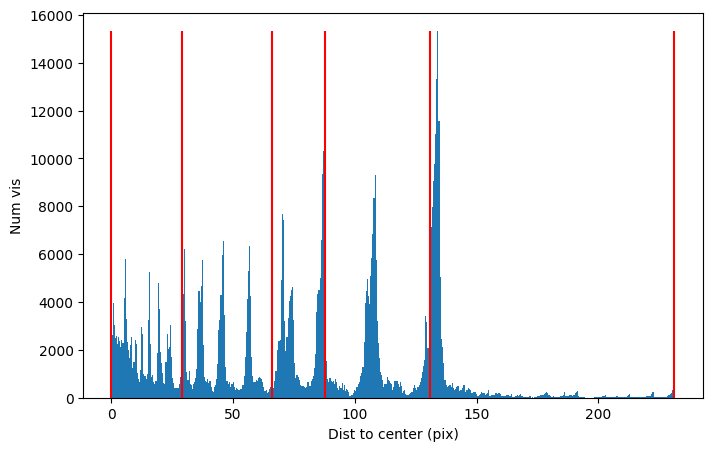

In [25]:
#bda.bda_and_export_to_ms2(output_dataset_name, vfull, decorr_limit, field_size_deg / 2, only_residual_decorr=False)
[vaveraged], _ = ingest.create_visibility_from_ms(output_dataset_name, use_weight_spec=True)
plot_uvcoverage([vaveraged])
bda.generate_telescope_histogram(vaveraged, show_partitions=True, num_partitions=5,\
                                     show_pixel_hist=True, n_pixels=512, pixel_size=cell_size_rad, output_file="../figures/bda99.png")